In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import seaborn as sns
import matplotlib.gridspec as gridspec
import ast
import sys
sys.path.append('../no_degeneracy/')
sys.path.append('../no_degeneracy/Prior/')
from mcmc import *
from parallel import *
from fit_prior import read_prior_par
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error

#Colors
#----------------------------------------------
colors_june={'0.5x':['#fee0d2', '#deebf7'],
       '1x':['#fc9272', '#9ecae1'],
       '2x':['#de2d26', '#3182bd'] }

color_noise=sns.color_palette("colorblind")[5]
color_data='#636363'
color_bms=colors_june['2x'][1]
color_ann=colors_june['2x'][0]
#-----------------------------------------------

In [7]:
#Read NN and BMS data
n=0;runid=0;function='tanh' #tanh, leaky_ReLU
realization=0
sigma=0.0
NPAR=10 #10, 20
steps=50000

resolution='1x' #'0.5x', '1x', '2x', '4e-3'
resolutions={'0.5x':'0.1', '1x':'0.05' , '2x': '0.025' , '4e-3x':'0.004' }

#Read NN data
file_model='NN_no_overfit_' + function + '_sigma_' + str(sigma) + '_r_' + str(realization) + '.csv'
model_d='../../data/nns/' + resolution + '_resolution/approximation/' + file_model

d=pd.read_csv(model_d)
dn=d[d['rep']==n]
dn.set_index('Unnamed: 0', inplace=True)
dn.index.name = None
dn=dn.reset_index(drop=True)
display(dn)

#Read BMS trace
filename='BMS_'+function+'_n_'+str(n)+'_sigma_'+str(sigma)+ '_r_' + str(realization) + '_res_' + resolutions[resolution] + '_trace_'+\
                str(steps)+'_prior_'+str(NPAR)+ '.csv'
trace=pd.read_csv('../../data/MSTraces/' + resolution + '_resolution/' + filename, sep=';', header=None, names=['t', 'H', 'expr', 'parvals', 'kk1', 'kk2','kk3'])

,x1,y,rep,noise,y_noise,ymodel
0,-1.95,0.052185,0.0,0.0,0.052185,0.049499
1,-1.90,0.056609,0.0,0.0,0.056609,0.054516
2,-1.85,0.061686,0.0,0.0,0.061686,0.060282
3,-1.80,0.067569,0.0,0.0,0.067569,0.066946
4,-1.75,0.074452,0.0,0.0,0.074452,0.074688
...,...,...,...,...,...,...
75,1.80,0.997513,0.0,0.0,0.997513,1.075924
76,1.85,0.997161,0.0,0.0,0.997161,1.078601
77,1.90,0.996811,0.0,0.0,0.996811,1.081174
78,1.95,0.996446,0.0,0.0,0.996446,1.083651


In [8]:
#Parameters to read models
VARS = ['x1',]
x = dn[[c for c in VARS]].copy()


if NPAR==10:
    prior_par = read_prior_par('../no_degeneracy/Prior/final_prior_param_sq.named_equations.nv1.np10.2017-10-18 18:07:35.089658.dat')
elif NPAR==20:
    prior_par = read_prior_par('../no_degeneracy/Prior/final_prior_param_sq.named_equations.nv1.np20.maxs200.2024-05-10 162907.551306.dat')

In [9]:
#Minimum description length model
y=dn.y_noise

minrow = trace[trace.H == min(trace.H)].iloc[0]
minH, minexpr, minparvals = minrow.H, minrow.expr, ast.literal_eval(minrow.parvals)

t = Tree(
    variables=list(x.columns),
    parameters=['a%d' % i for i in range(NPAR)],
    x=x, y=y,
    prior_par=prior_par,
    max_size=200,
    from_string=minexpr,
)

t.set_par_values(deepcopy(minparvals))

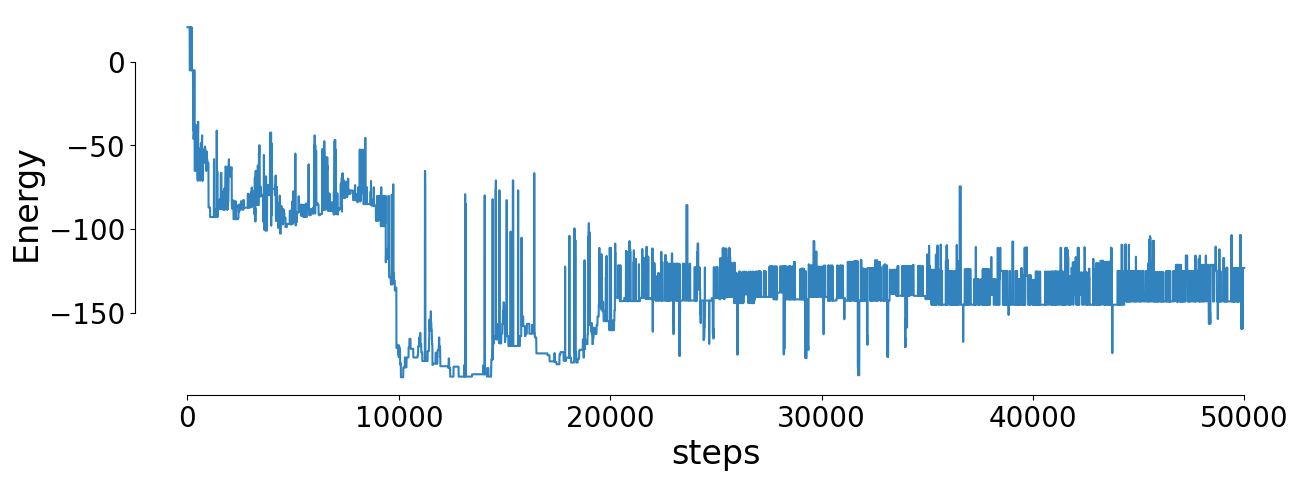

In [10]:
Nini = 00
plt.figure(figsize=(15, 5))




#Define figure size in cm                                                                           
Extensions=['.svg']

#Fonts and sizes                                                                                    
size_axis=7;size_ticks=6;size_title=5
line_w=1;marker_s=3 #width and marker size                                                           
#plt.title(str(function) + ', ' + 'n=' + str(n) +', r=' + str(realization))
plt.plot(trace.t[trace.t > Nini], trace.H[trace.t > Nini], color=color_bms)
plt.xticks(fontsize=20);plt.yticks(fontsize=20)
plt.xlabel('steps',fontsize=24);plt.ylabel('Energy',fontsize=24)
#plt.scatter(minrow['t'], minH,color='r')
sns.despine(trim=True)

Name_figure='Energy_' + function + '_n_' + str(n) + '_sigma_' + str(sigma) + '_r_'  + str(realization) + '_par_' + str(NPAR)

for ext in Extensions:
        plt.savefig('../../results/' + Name_figure + ext,dpi=300)

 
plt.show()

80


,x1,y,rep,noise,y_noise,ymodel,ybms
49,0.50,0.954137,0.0,0.0,0.954137,0.929160,0.953366
50,0.55,0.959684,0.0,0.0,0.959684,0.939389,0.958773
51,0.60,0.963970,0.0,0.0,0.963970,0.949109,0.963194
52,0.65,0.967457,0.0,0.0,0.967457,0.958329,0.967092
53,0.70,0.970496,0.0,0.0,0.970496,0.967066,0.970669
54,0.75,0.973335,0.0,0.0,0.973335,0.975336,0.973981
55,0.80,0.976130,0.0,0.0,0.976130,0.983158,0.977039
56,0.85,0.978960,0.0,0.0,0.978960,0.990554,0.979839
57,0.90,0.981836,0.0,0.0,0.981836,0.997545,0.982381
58,0.95,0.984725,0.0,0.0,0.984725,1.004151,0.984663


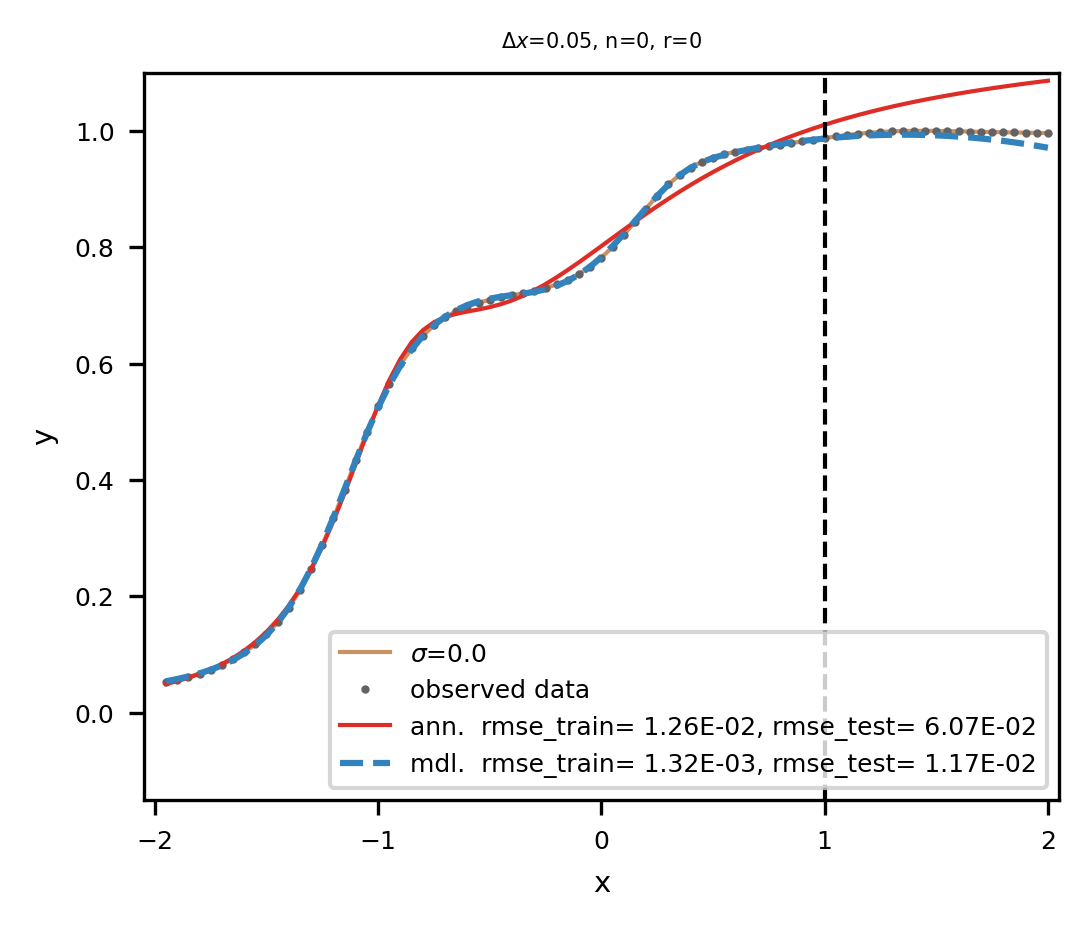

In [11]:
#Plot

#Validation and train borders
n_points=int(len(dn.index))
print(n_points)
train_fraction=5/8;valid_fraction=1/8;test_fraction=0.2
train_size_ann=int(n_points*train_fraction)
train_size_bms=train_size_ann + int(n_points*valid_fraction)


train_border=dn.loc[train_size_bms-1]['x1']

dplot = deepcopy(dn)
dplot['ybms'] = t.predict(x)
display(dplot.loc[train_size_ann-1:])

#ann errors
rmse_nn_train=root_mean_squared_error(dplot.loc[:train_size_bms-1]['ymodel'],dplot.loc[:train_size_bms -1]['y'])
rmse_nn_test=root_mean_squared_error(dplot.loc[train_size_bms-1:]['ymodel'],dplot.loc[train_size_bms -1:]['y'])
#rmse_nn_validation=root_mean_squared_error(dplot.iloc[validation_points]['ymodel'],dplot.iloc[validation_points]['y'])

#bms errors
rmse_mdl=root_mean_squared_error(dplot.ybms,dn.y)
rmse_mdl_train=root_mean_squared_error(dplot.loc[:train_size_bms-1]['ybms'],dn.loc[:train_size_bms-1]['y'])
rmse_mdl_test =root_mean_squared_error(dplot.loc[train_size_bms-1:]['ybms'],dn.loc[train_size_bms-1:]['y'])

 
#Define figure size in cm                                                                           
cm = 1/2.54 #convert inch to cm                                                                     
width = 10*cm; height=8*cm

Extensions=['.png']

#Fonts and sizes                                                                                    
size_axis=7;size_ticks=6;size_title=5
line_w=1;marker_s=3 #width and marker size                                                          


fig=figure(figsize=(width,height), dpi=300)           


plt.plot(dn['x1'], dn['y_noise'],linewidth=line_w, markersize=2, color=color_noise,label=r'$\sigma$=' + str(sigma) )
plt.plot(dn['x1'], dn['y'],'.', markersize=2, color=color_data,label='observed data') 
plt.plot(dn['x1'], dn['ymodel'],linewidth=line_w, color=color_ann, label='ann.  rmse_train= %.2E, rmse_test= %.2E' % ( rmse_nn_train, rmse_nn_test))
plt.plot(dplot.x1, dplot.ybms, color=color_bms, linestyle='--',label='mdl.  rmse_train= %.2E, rmse_test= %.2E' % ( rmse_mdl_train, rmse_mdl_test)) 
                                                                                

plt.axvline(x=train_border,linestyle='--',linewidth=line_w, color='k')

#plt.title('$%s$' % t.latex(),fontsize=size_title)
plt.title(r'$\Delta x$=%s, n=%d, r=%d' % (resolutions[resolution], n, realization),fontsize=size_title)
plt.xlabel('x',fontsize=size_axis);plt.ylabel('y',fontsize=size_axis)
plt.xticks(fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
plt.legend(loc='best', fontsize=size_ticks)

plt.xlim(-2.05,2.05);plt.ylim(-0.15,1.1)  


Name_figure='Prediction_' + resolution + '_' + function + '_n_' + str(n) + '_sigma_' + str(sigma) + '_r_'  + str(realization) + '_par_' + str(NPAR)

    
for ext in Extensions:
        plt.savefig('../../results/' + Name_figure +ext,dpi=300)

plt.show()